In [62]:
import sys
from pathlib import Path

import dask.array as da
import geodatasets
import geopandas as gpd
import icechunk
import numpy as np
import rioxarray
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sys.path.insert(0, str(Path.cwd().parent))
from icechunk_github_actions_demo import Config, get_processing_status_gdf

# Use config_with_secrets_v1.txt for local runs; config_v1.txt reads credentials from env vars.
config = Config("config/config_with_secrets_v1.txt")

print("YEARS:", config.YEARS)
print("RESOLUTION:", config.RESOLUTION)
print("TILE_SIZE_DEG:", config.TILE_SIZE_DEG)
print("PIXELS_PER_TILE:", config.PIXELS_PER_TILE)
print("Global geobox:", config.global_geobox)

YEARS: [2020, 2021, 2022]
RESOLUTION: 0.01
TILE_SIZE_DEG: 10.0
PIXELS_PER_TILE: 1000
Global geobox: GeoBox((18000, 36000), Affine(0.01, 0.0, -180.0,
       0.0, -0.01, 90.0), CRS('EPSG:4326'))


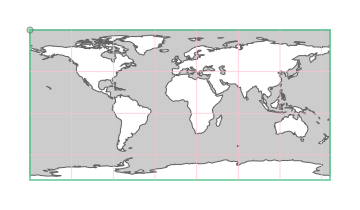

In [63]:
config.global_geobox

In [64]:
# config.global_geobox_tiles_gdf derives tile geometries from the global geobox
tiles_gdf = config.global_geobox_tiles_gdf

# Natural Earth land polygons via geodatasets
land_gdf = gpd.read_file(geodatasets.get_url("naturalearth land"))

# Mark tiles that intersect land
tiles_gdf["land"] = tiles_gdf.intersects(land_gdf.union_all())

tiles_gdf.to_file(config.TILE_LIST_PATH, driver="GeoJSON")
print(f"{tiles_gdf['land'].sum()} land tiles out of {len(tiles_gdf)} total. Geojson written to {config.TILE_LIST_PATH}")
tiles_gdf.head()

381 land tiles out of 648 total. Geojson written to /home/eric/repos/icechunk_github_actions_zarr_synergy/icechunk_github_actions_demo/tile_list.geojson


,row,col,geometry,land
0,0,0,"POLYGON ((-180 90, -180 80, -170 80, -170 90, ...",False
1,0,1,"POLYGON ((-170 90, -170 80, -160 80, -160 90, ...",False
2,0,2,"POLYGON ((-160 90, -160 80, -150 80, -150 90, ...",False
3,0,3,"POLYGON ((-150 90, -150 80, -140 80, -140 90, ...",False
4,0,4,"POLYGON ((-140 90, -140 80, -130 80, -130 90, ...",False


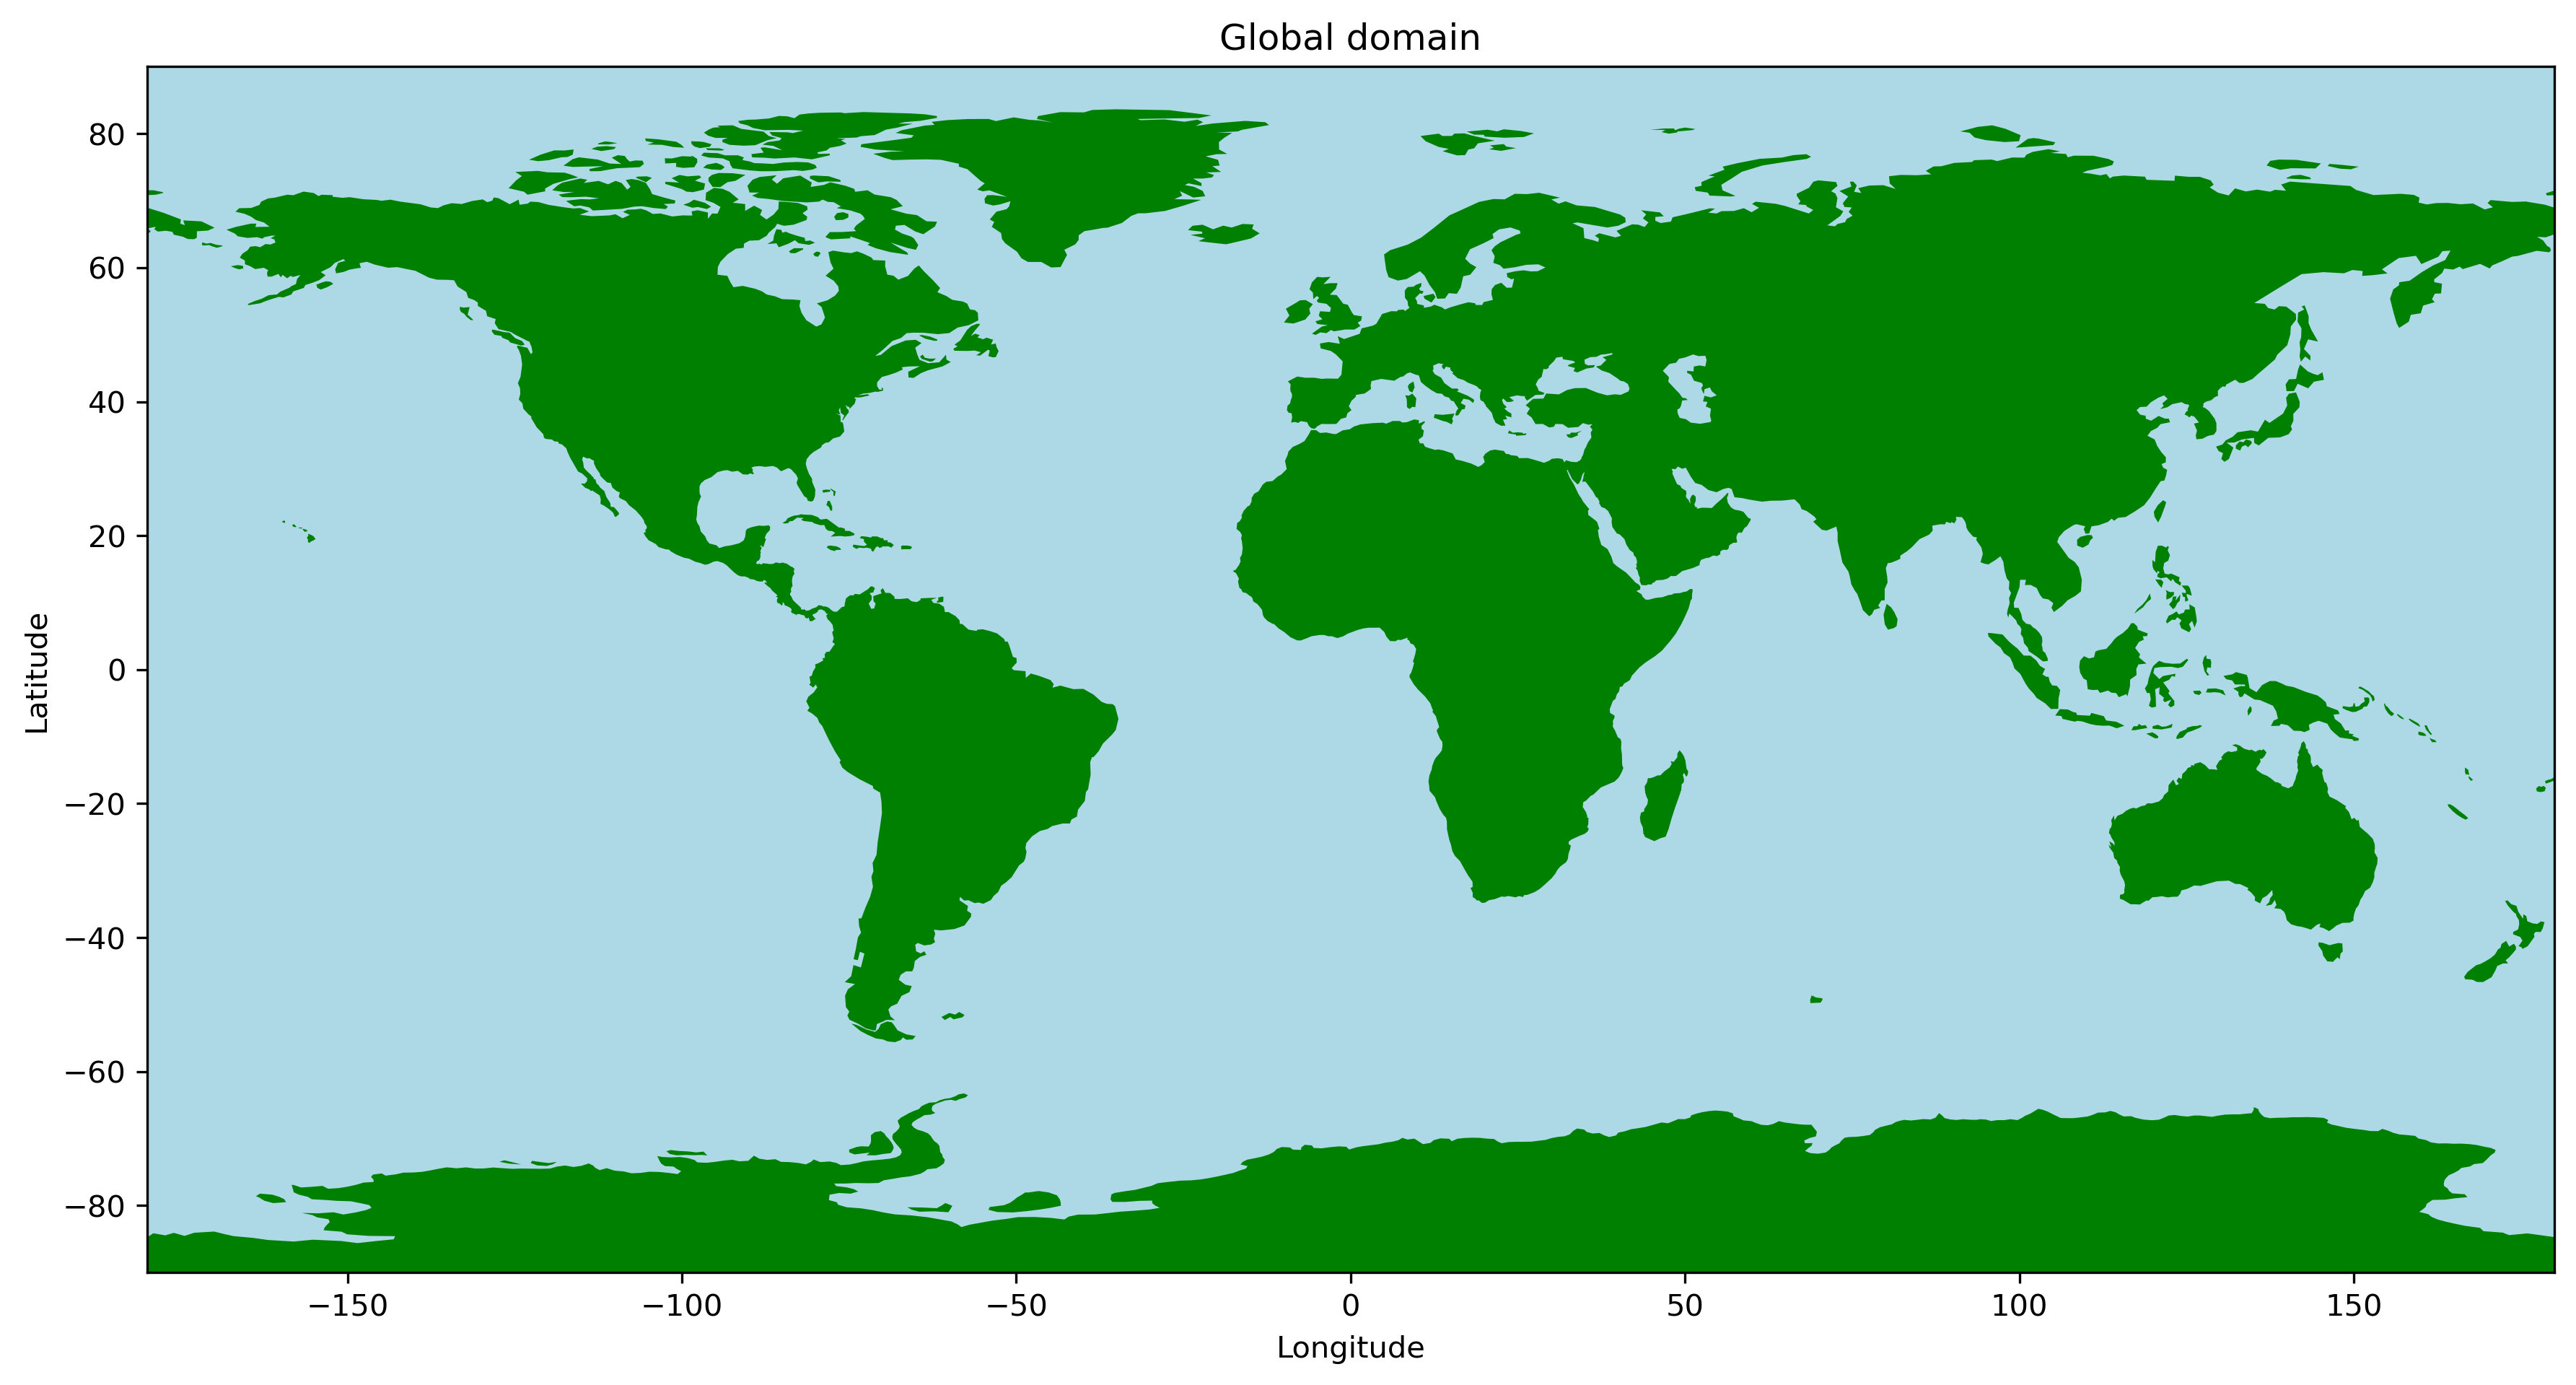

In [66]:
f, ax = plt.subplots(figsize=(12, 7), dpi=300)

land_gdf.plot(ax=ax, color="green", zorder=0)
# make background blue
ax.set_facecolor("lightblue")


ax.set_title("Global domain")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")


ax.set_xlim(tiles_gdf.total_bounds[0], tiles_gdf.total_bounds[2])
ax.set_ylim(tiles_gdf.total_bounds[1], tiles_gdf.total_bounds[3])

f.tight_layout()
f.savefig('conceptual_figure/step_1_global_domain.png', dpi=300)

/tmp/ipykernel_6845/462507798.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/462507798.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/462507798.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/462507798.py:16: UserWa

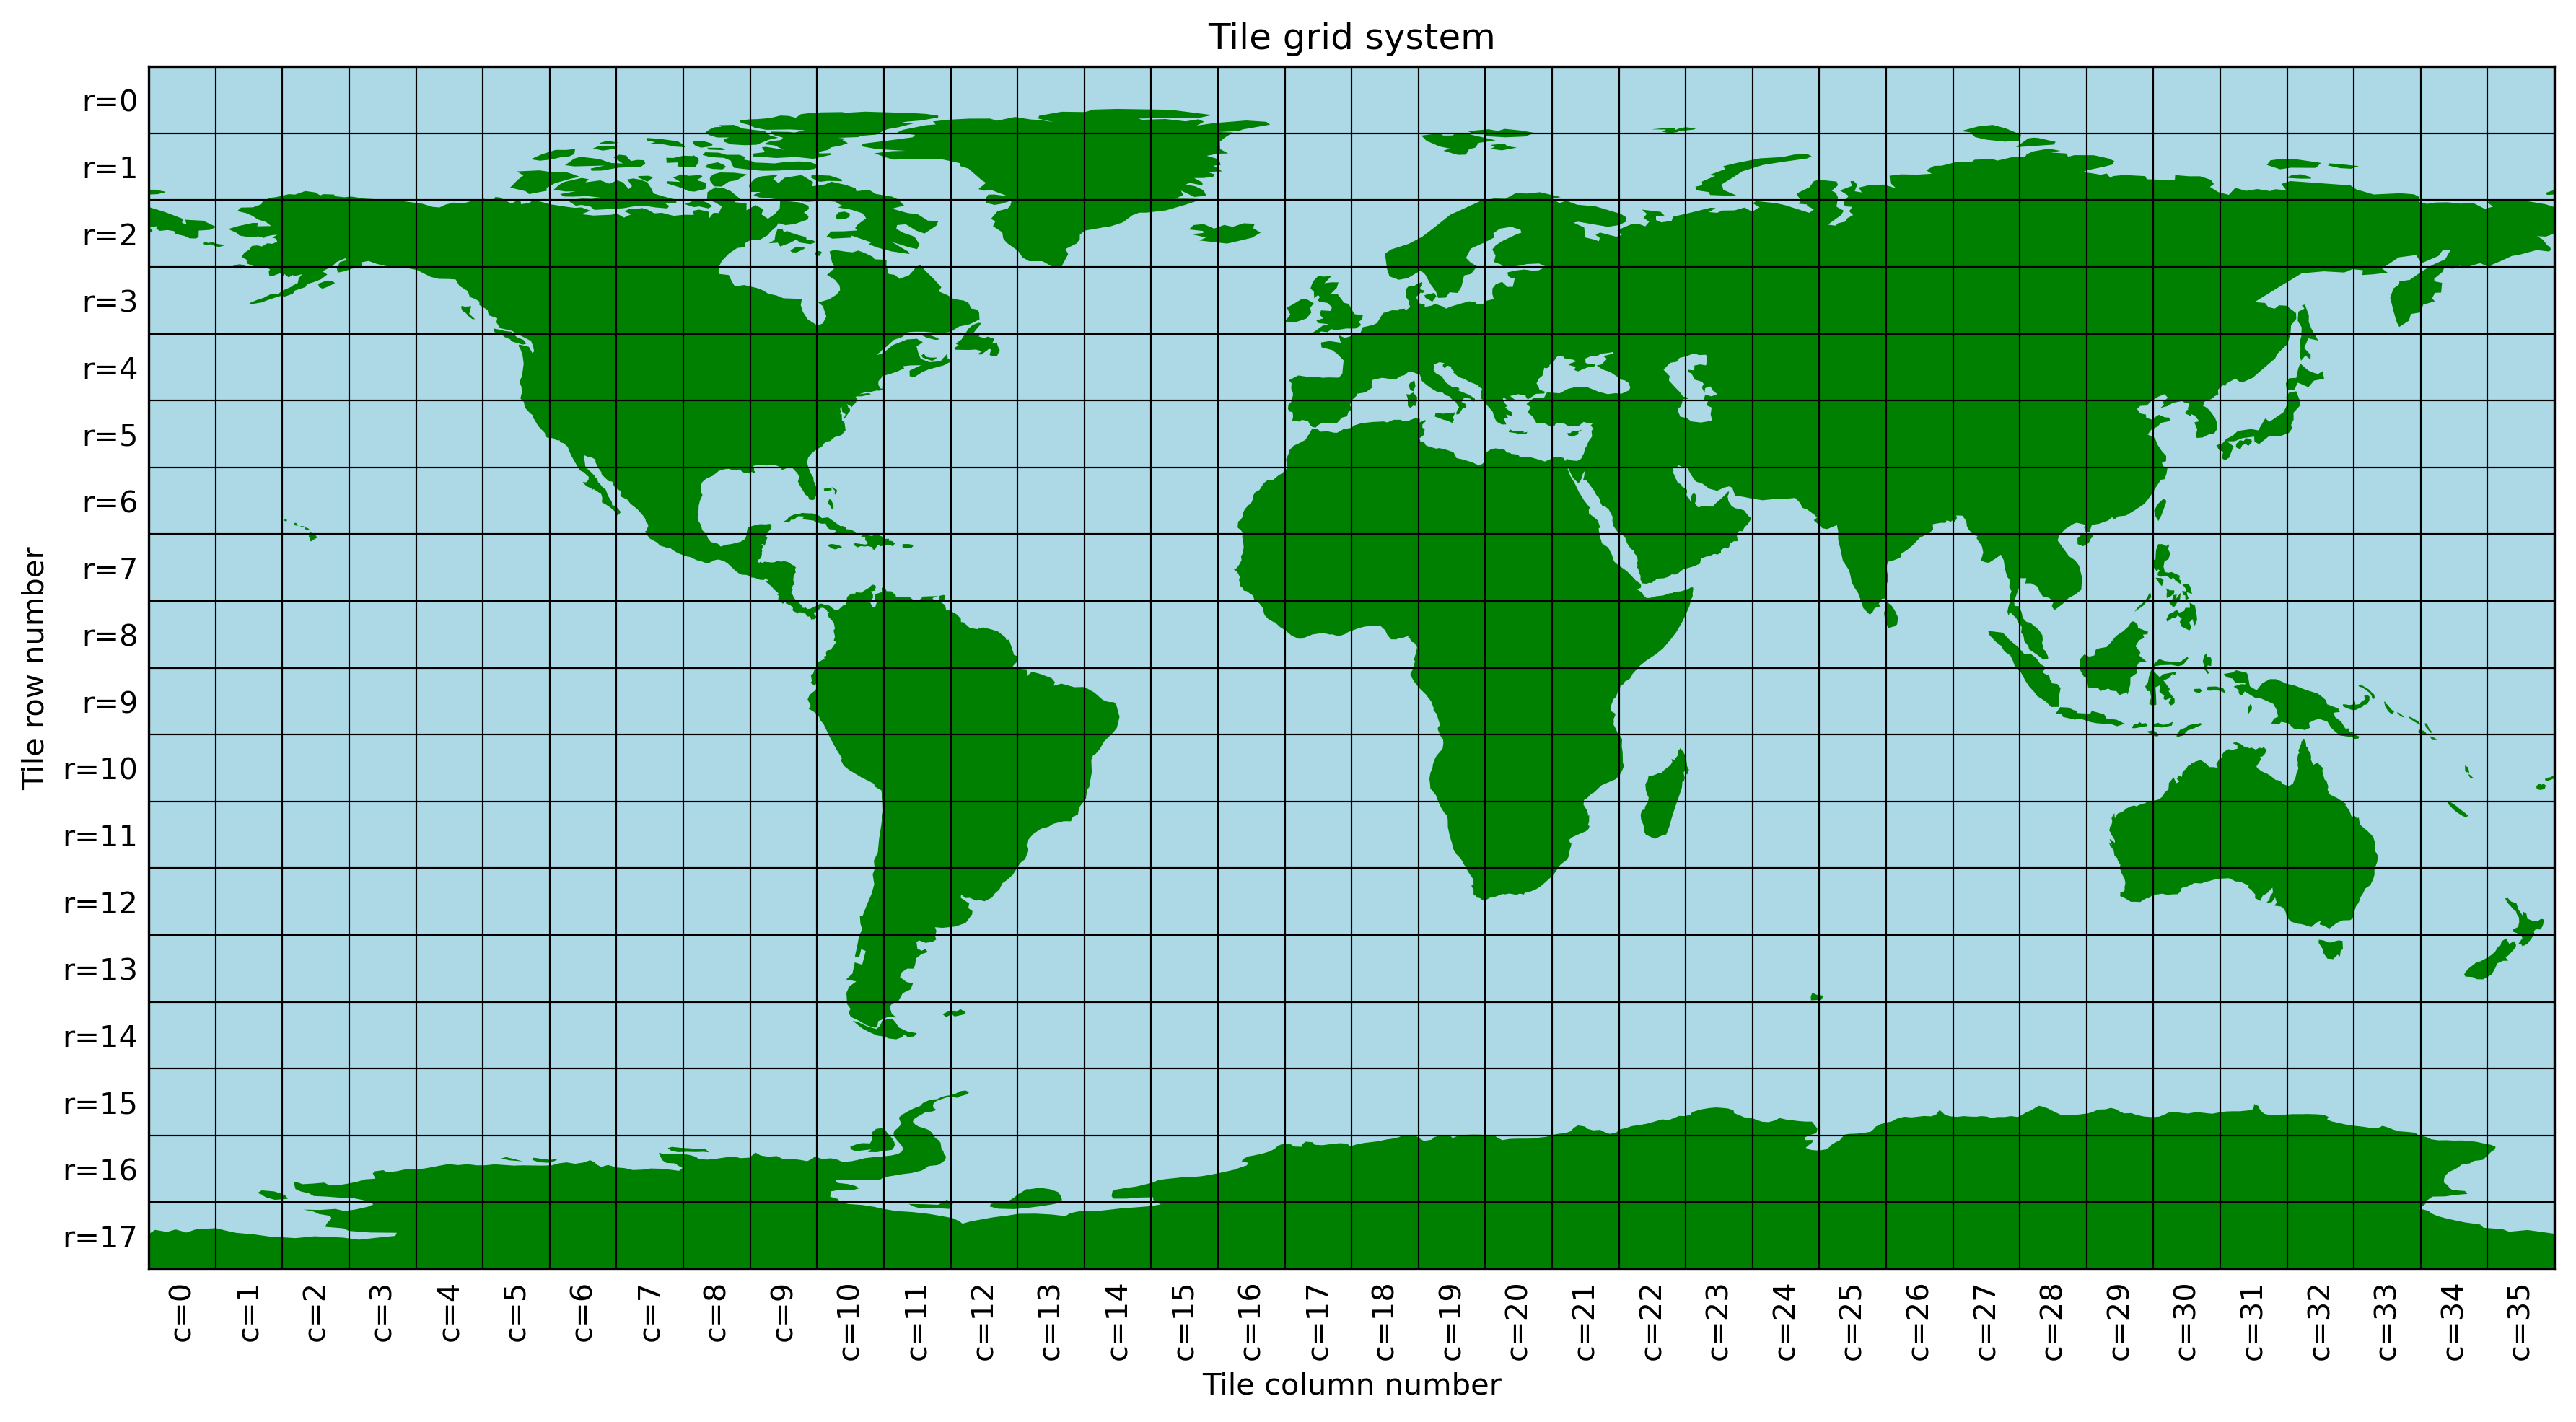

In [67]:
f, ax = plt.subplots(figsize=(12, 7), dpi=300)

land_gdf.plot(ax=ax, color="green", zorder=0)
# make background blue
tiles_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5, zorder=1)

ax.set_facecolor("lightblue")


ax.set_title("Tile grid system")
ax.set_xlabel("Tile column number")
ax.set_ylabel("Tile row number")

col_values = sorted(tiles_gdf["col"].unique())
row_values = sorted(tiles_gdf["row"].unique(), reverse=True)
col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
row_coords = [tiles_gdf[tiles_gdf["row"] == v].geometry.centroid.y.mean() for v in row_values]

ax.set_xticks(col_coords)
ax.set_xticklabels([f"c={h}" for h in col_values], rotation=90)
ax.set_yticks(row_coords)
ax.set_yticklabels([f"r={v}" for v in row_values])
ax.tick_params(axis="both", which="both", length=0)
ax.set_xlim(tiles_gdf.total_bounds[0], tiles_gdf.total_bounds[2])
ax.set_ylim(tiles_gdf.total_bounds[1], tiles_gdf.total_bounds[3])


f.tight_layout()
f.savefig('conceptual_figure/step_2_global_domain_with_grid.png', dpi=300)

/tmp/ipykernel_6845/1686354818.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/1686354818.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/1686354818.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/1686354818.py:16: Us

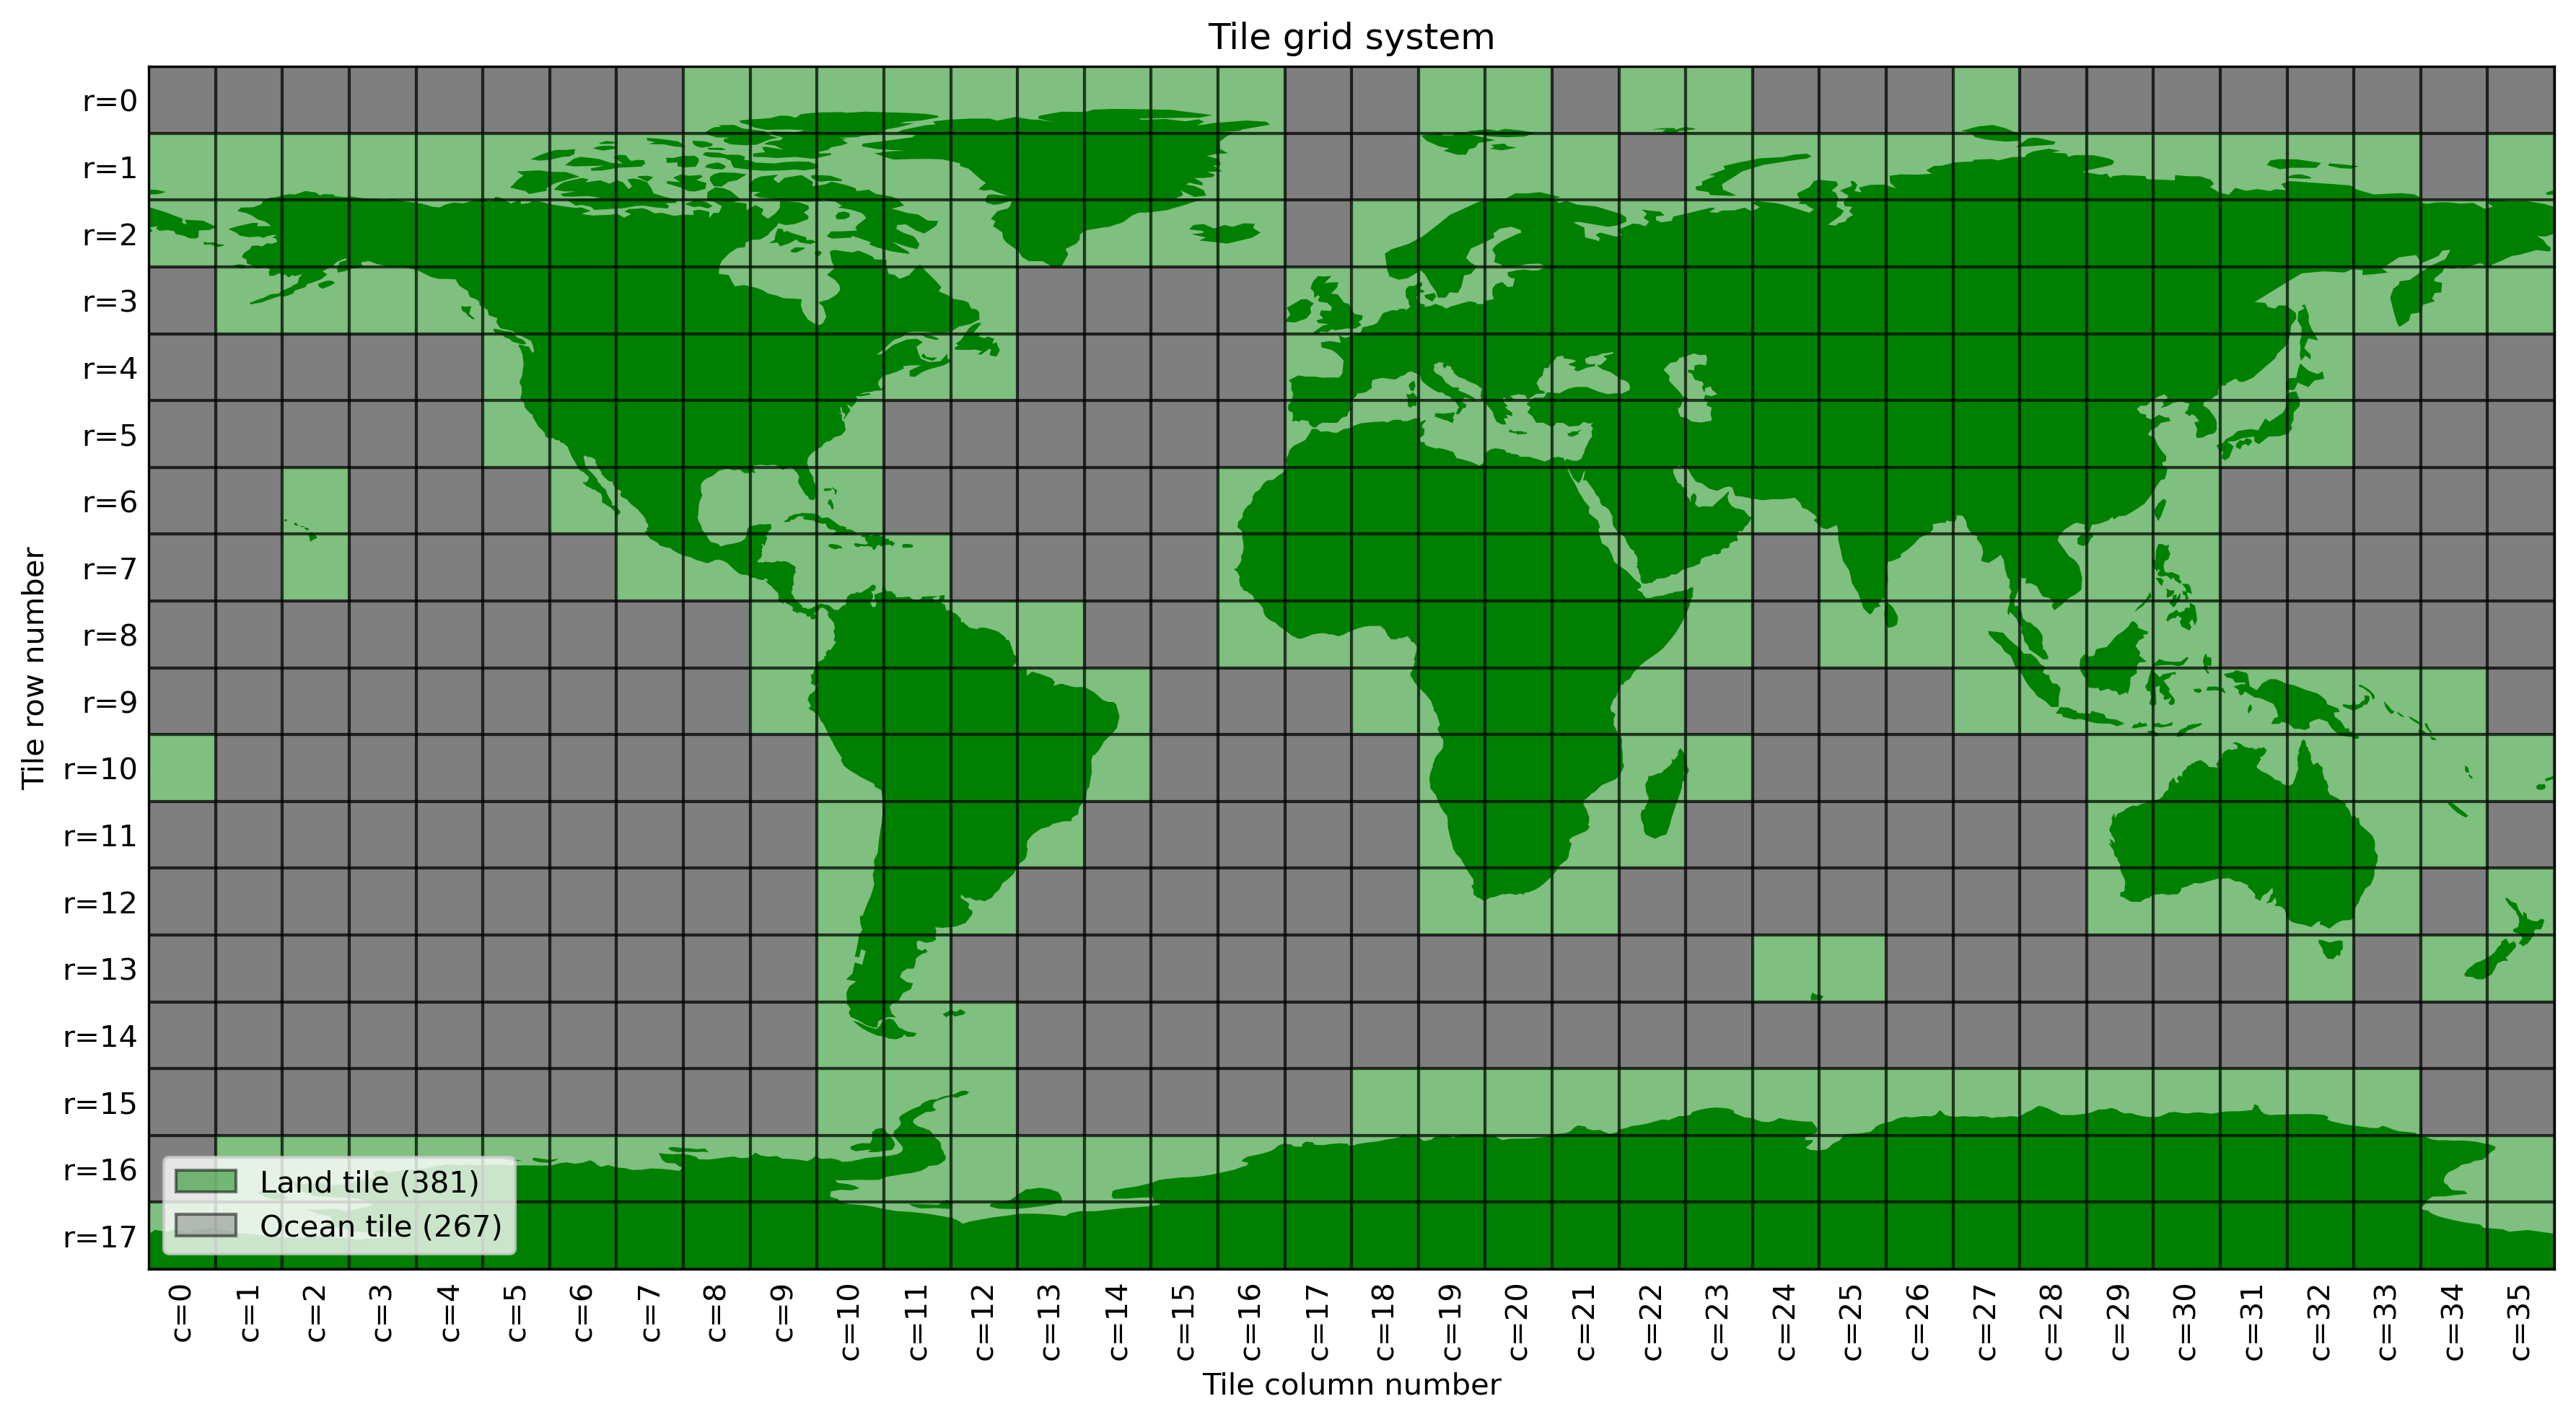

In [68]:
f, ax = plt.subplots(figsize=(12, 7), dpi=300)

land_gdf.plot(ax=ax, color="green", zorder=0)
tiles_gdf.plot(
    ax=ax,
    facecolor=tiles_gdf["land"].map({True: "green", False: "none"}),
    edgecolor="black", alpha=0.5, zorder=1,
)

ax.set_title("Tile grid system")
ax.set_xlabel("Tile column number")
ax.set_ylabel("Tile row number")

col_values = sorted(tiles_gdf["col"].unique())
row_values = sorted(tiles_gdf["row"].unique(), reverse=True)
col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
row_coords = [tiles_gdf[tiles_gdf["row"] == v].geometry.centroid.y.mean() for v in row_values]

ax.set_xticks(col_coords)
ax.set_xticklabels([f"c={h}" for h in col_values], rotation=90)
ax.set_yticks(row_coords)
ax.set_yticklabels([f"r={v}" for v in row_values])
ax.tick_params(axis="both", which="both", length=0)
ax.set_xlim(tiles_gdf.total_bounds[0], tiles_gdf.total_bounds[2])
ax.set_ylim(tiles_gdf.total_bounds[1], tiles_gdf.total_bounds[3])

legend_elements = [
    Patch(facecolor="green", alpha=0.5, edgecolor="black",
          label=f'Land tile ({tiles_gdf["land"].sum()})'),
    Patch(facecolor="grey", alpha=0.5, edgecolor="black",
          label=f'Ocean tile ({(~tiles_gdf["land"]).sum()})'),
]
ax.legend(handles=legend_elements, loc="lower left")
f.tight_layout()
f.savefig('conceptual_figure/step_3_land_tile_selection.png', dpi=300)

In [24]:
storage = icechunk.azure_storage(
    account=config.AZURE_STORAGE_ACCOUNT,
    container=config.AZURE_CONTAINER,
    prefix=config.ICECHUNK_PREFIX,
    sas_token=config.AZURE_STORAGE_SAS_TOKEN,
)
repo = icechunk.Repository.open(storage)

In [73]:
status_gdf = get_processing_status_gdf(repo, config.TILE_LIST_PATH, config.YEARS)
status_gdf

,row,col,land,geometry,status,2020_output_valid_pixels,2020_input_granules,2021_output_valid_pixels,2021_input_granules,2022_output_valid_pixels,2022_input_granules
0,0,0,False,"POLYGON ((-180 90, -180 80, -170 80, -170 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,False,"POLYGON ((-170 90, -170 80, -160 80, -160 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2,False,"POLYGON ((-160 90, -160 80, -150 80, -150 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
3,0,3,False,"POLYGON ((-150 90, -150 80, -140 80, -140 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
4,0,4,False,"POLYGON ((-140 90, -140 80, -130 80, -130 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
643,17,31,True,"POLYGON ((130 -80, 130 -90, 140 -90, 140 -80, ...",processed,574998.0,182.0,574998.0,186.0,574998.0,178.0
644,17,32,True,"POLYGON ((140 -80, 140 -90, 150 -90, 150 -80, ...",processed,604389.0,182.0,604389.0,186.0,604389.0,178.0
645,17,33,True,"POLYGON ((150 -80, 150 -90, 160 -90, 160 -80, ...",processed,377137.0,182.0,377137.0,186.0,377137.0,178.0
646,17,34,True,"POLYGON ((160 -80, 160 -90, 170 -90, 170 -80, ...",processed,67576.0,182.0,67576.0,186.0,67576.0,178.0


In [74]:
# create mock processing status for conceptual figure
mock_status_gdf = status_gdf.copy()
mock_status_gdf

,row,col,land,geometry,status,2020_output_valid_pixels,2020_input_granules,2021_output_valid_pixels,2021_input_granules,2022_output_valid_pixels,2022_input_granules
0,0,0,False,"POLYGON ((-180 90, -180 80, -170 80, -170 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,False,"POLYGON ((-170 90, -170 80, -160 80, -160 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2,False,"POLYGON ((-160 90, -160 80, -150 80, -150 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
3,0,3,False,"POLYGON ((-150 90, -150 80, -140 80, -140 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
4,0,4,False,"POLYGON ((-140 90, -140 80, -130 80, -130 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
643,17,31,True,"POLYGON ((130 -80, 130 -90, 140 -90, 140 -80, ...",processed,574998.0,182.0,574998.0,186.0,574998.0,178.0
644,17,32,True,"POLYGON ((140 -80, 140 -90, 150 -90, 150 -80, ...",processed,604389.0,182.0,604389.0,186.0,604389.0,178.0
645,17,33,True,"POLYGON ((150 -80, 150 -90, 160 -90, 160 -80, ...",processed,377137.0,182.0,377137.0,186.0,377137.0,178.0
646,17,34,True,"POLYGON ((160 -80, 160 -90, 170 -90, 170 -80, ...",processed,67576.0,182.0,67576.0,186.0,67576.0,178.0


In [76]:
# set all land tiles to unprocessed for conceptual figure
mock_status_gdf.loc[mock_status_gdf["status"] != "ocean", "status"] = "unprocessed"

counts = mock_status_gdf["status"].value_counts()
land_count = int((mock_status_gdf["status"] != "ocean").sum())
processed_count = int(counts.get("processed", 0))
nodata_count = int(counts.get("nodata", 0))
unprocessed_count = int(counts.get("unprocessed", 0))

print(f"Land tiles:   {land_count}")
print(f"Processed:    {processed_count}")
print(f"No-data:      {nodata_count}")
print(f"Unprocessed:  {unprocessed_count}")
print(f"Progress:     {100 * (processed_count + nodata_count) / land_count:.1f}%")

mock_status_gdf

Land tiles:   381
Processed:    0
No-data:      0
Unprocessed:  381
Progress:     0.0%


,row,col,land,geometry,status,2020_output_valid_pixels,2020_input_granules,2021_output_valid_pixels,2021_input_granules,2022_output_valid_pixels,2022_input_granules
0,0,0,False,"POLYGON ((-180 90, -180 80, -170 80, -170 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,False,"POLYGON ((-170 90, -170 80, -160 80, -160 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2,False,"POLYGON ((-160 90, -160 80, -150 80, -150 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
3,0,3,False,"POLYGON ((-150 90, -150 80, -140 80, -140 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
4,0,4,False,"POLYGON ((-140 90, -140 80, -130 80, -130 90, ...",ocean,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
643,17,31,True,"POLYGON ((130 -80, 130 -90, 140 -90, 140 -80, ...",unprocessed,574998.0,182.0,574998.0,186.0,574998.0,178.0
644,17,32,True,"POLYGON ((140 -80, 140 -90, 150 -90, 150 -80, ...",unprocessed,604389.0,182.0,604389.0,186.0,604389.0,178.0
645,17,33,True,"POLYGON ((150 -80, 150 -90, 160 -90, 160 -80, ...",unprocessed,377137.0,182.0,377137.0,186.0,377137.0,178.0
646,17,34,True,"POLYGON ((160 -80, 160 -90, 170 -90, 170 -80, ...",unprocessed,67576.0,182.0,67576.0,186.0,67576.0,178.0


/tmp/ipykernel_6845/697707397.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/697707397.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/697707397.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ip

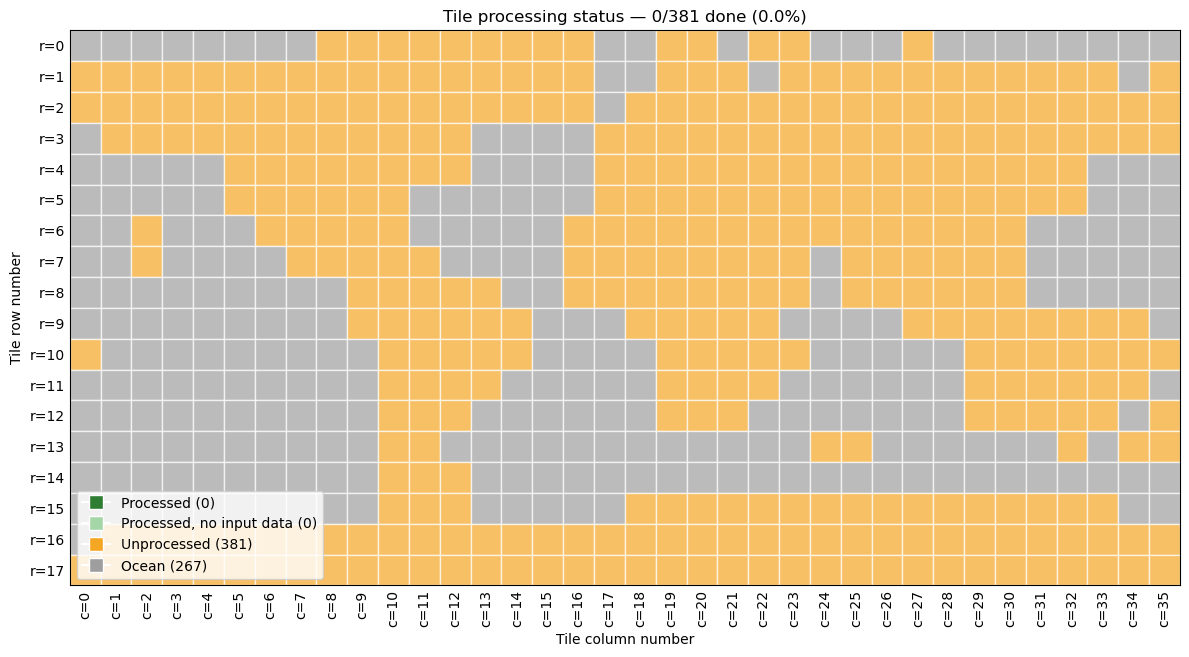

In [77]:
color_map = {
    "processed": "#2e7d32",
    "nodata": "#a5d6a7",
    "unprocessed": "#f5a623",
    "ocean": "#9e9e9e",
}

f, ax = plt.subplots(figsize=(12, 7))
status_gdf.plot(
    ax=ax,
    color=mock_status_gdf["status"].map(color_map),
    edgecolor="white",
    alpha=0.7,
)

# ax.set_xlim(-180, 180)
# ax.set_ylim(-90, 90)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

ax.set_xlabel("Tile column number")
ax.set_ylabel("Tile row number")

col_values = sorted(mock_status_gdf["col"].unique())
row_values = sorted(mock_status_gdf["row"].unique(), reverse=True)
col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
row_coords = [mock_status_gdf[mock_status_gdf["row"] == v].geometry.centroid.y.mean() for v in row_values]

ax.set_xticks(col_coords)
ax.set_xticklabels([f"c={h}" for h in col_values], rotation=90)
ax.set_yticks(row_coords)
ax.set_yticklabels([f"r={v}" for v in row_values])
ax.tick_params(axis="both", which="both", length=0)
ax.set_xlim(mock_status_gdf.total_bounds[0], mock_status_gdf.total_bounds[2])
ax.set_ylim(mock_status_gdf.total_bounds[1], mock_status_gdf.total_bounds[3])

ax.set_title(
    f"Tile processing status — {processed_count + nodata_count}/{land_count} done "
    f"({100 * (processed_count + nodata_count) / land_count:.1f}%)"
)
handles = [
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed ({processed_count})", markerfacecolor=color_map["processed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed, no input data ({nodata_count})", markerfacecolor=color_map["nodata"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Unprocessed ({unprocessed_count})", markerfacecolor=color_map["unprocessed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Ocean ({int(counts.get('ocean', 0))})", markerfacecolor=color_map["ocean"], markersize=10),
]
ax.legend(handles=handles, loc="lower left")
f.tight_layout()
f.savefig('conceptual_figure/step_4_tile_processing_status_0pct.png', dpi=300)

Land tiles:   381
Processed:    1
No-data:      0
Unprocessed:  380
Progress:     0.3%


/tmp/ipykernel_6845/989822413.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/989822413.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/989822413.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ip

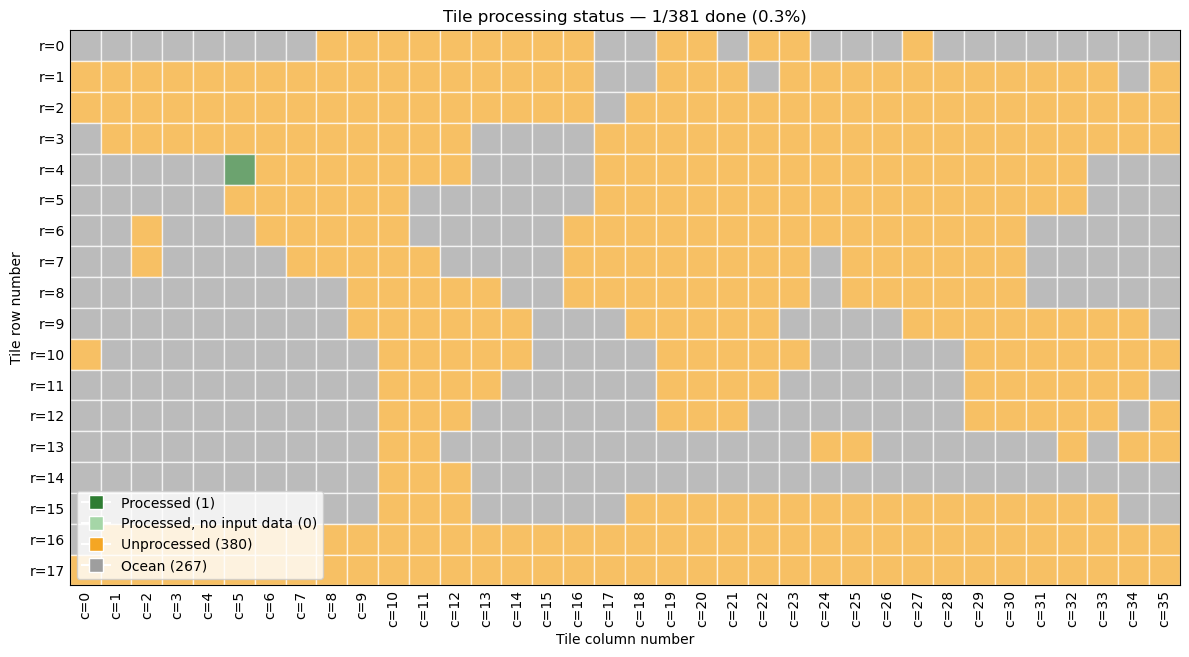

In [70]:
mock_status_gdf = status_gdf.copy()
mock_status_gdf.loc[mock_status_gdf["status"] != "ocean", "status"] = "unprocessed"

# set tile row 4 col 5 to processed for conceptual figure
mock_status_gdf.loc[(mock_status_gdf["row"] == 4) & (mock_status_gdf["col"] == 5), "status"] = "processed"

counts = mock_status_gdf["status"].value_counts()
land_count = int((mock_status_gdf["status"] != "ocean").sum())
processed_count = int(counts.get("processed", 0))
nodata_count = int(counts.get("nodata", 0))
unprocessed_count = int(counts.get("unprocessed", 0))

print(f"Land tiles:   {land_count}")
print(f"Processed:    {processed_count}")
print(f"No-data:      {nodata_count}")
print(f"Unprocessed:  {unprocessed_count}")
print(f"Progress:     {100 * (processed_count + nodata_count) / land_count:.1f}%")

color_map = {
    "processed": "#2e7d32",
    "nodata": "#a5d6a7",
    "unprocessed": "#f5a623",
    "ocean": "#9e9e9e",
}

f, ax = plt.subplots(figsize=(12, 7))
status_gdf.plot(
    ax=ax,
    color=mock_status_gdf["status"].map(color_map),
    edgecolor="white",
    alpha=0.7,
)


ax.set_xlabel("Tile column number")
ax.set_ylabel("Tile row number")

col_values = sorted(mock_status_gdf["col"].unique())
row_values = sorted(mock_status_gdf["row"].unique(), reverse=True)
col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
row_coords = [mock_status_gdf[mock_status_gdf["row"] == v].geometry.centroid.y.mean() for v in row_values]

ax.set_xticks(col_coords)
ax.set_xticklabels([f"c={h}" for h in col_values], rotation=90)
ax.set_yticks(row_coords)
ax.set_yticklabels([f"r={v}" for v in row_values])
ax.tick_params(axis="both", which="both", length=0)
ax.set_xlim(mock_status_gdf.total_bounds[0], mock_status_gdf.total_bounds[2])
ax.set_ylim(mock_status_gdf.total_bounds[1], mock_status_gdf.total_bounds[3])

ax.set_title(
    f"Tile processing status — {processed_count + nodata_count}/{land_count} done "
    f"({100 * (processed_count + nodata_count) / land_count:.1f}%)"
)
handles = [
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed ({processed_count})", markerfacecolor=color_map["processed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed, no input data ({nodata_count})", markerfacecolor=color_map["nodata"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Unprocessed ({unprocessed_count})", markerfacecolor=color_map["unprocessed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Ocean ({int(counts.get('ocean', 0))})", markerfacecolor=color_map["ocean"], markersize=10),
]
ax.legend(handles=handles, loc="lower left")
f.tight_layout()

f.savefig('conceptual_figure/step_5_tile_processing_status_1pct.png', dpi=300)

Land tiles:   381
Processed:    64
No-data:      5
Unprocessed:  312
Progress:     18.1%


/tmp/ipykernel_6845/646601136.py:45: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/646601136.py:45: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/646601136.py:45: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ip

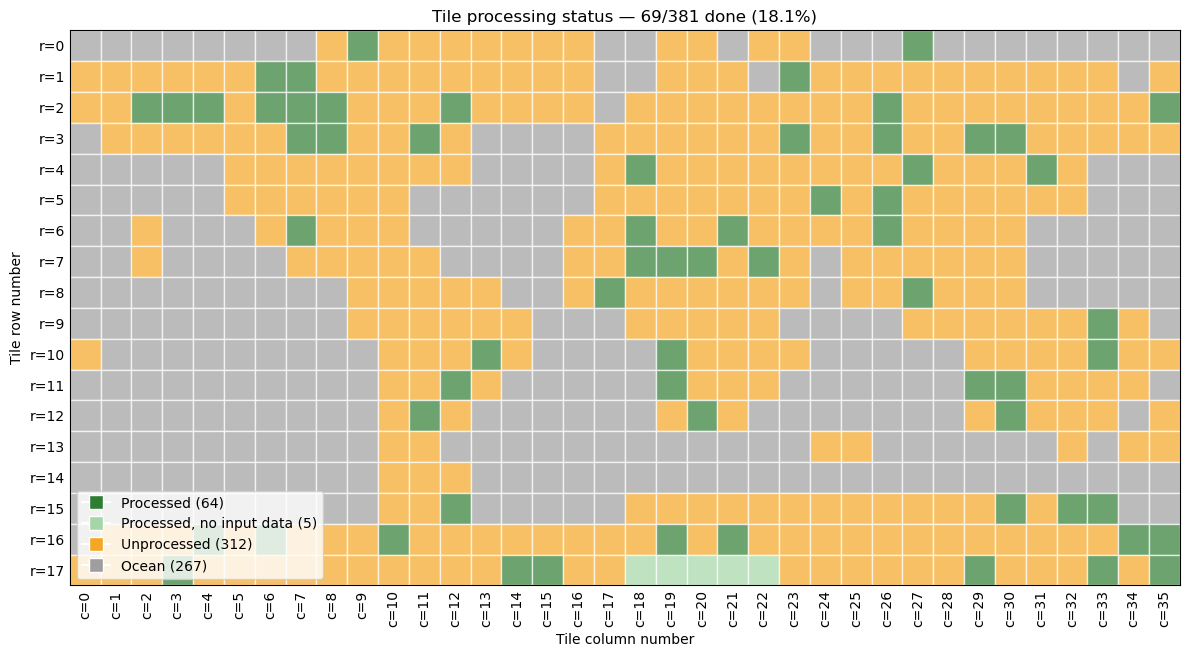

In [71]:
# show set half of processed tiles to unprocessed for conceptual figure
mock_status_gdf = status_gdf.copy()

processed_tiles = mock_status_gdf[mock_status_gdf["status"] == "processed"]
half_processed_tiles = processed_tiles.sample(frac=0.83, random_state=42).index
mock_status_gdf.loc[half_processed_tiles, "status"] = "unprocessed"

counts = mock_status_gdf["status"].value_counts()
land_count = int((mock_status_gdf["status"] != "ocean").sum())
processed_count = int(counts.get("processed", 0))
nodata_count = int(counts.get("nodata", 0))
unprocessed_count = int(counts.get("unprocessed", 0))

print(f"Land tiles:   {land_count}")
print(f"Processed:    {processed_count}")
print(f"No-data:      {nodata_count}")
print(f"Unprocessed:  {unprocessed_count}")
print(f"Progress:     {100 * (processed_count + nodata_count) / land_count:.1f}%")

color_map = {
    "processed": "#2e7d32",
    "nodata": "#a5d6a7",
    "unprocessed": "#f5a623",
    "ocean": "#9e9e9e",
}

f, ax = plt.subplots(figsize=(12, 7))
status_gdf.plot(
    ax=ax,
    color=mock_status_gdf["status"].map(color_map),
    edgecolor="white",
    alpha=0.7,
)

# ax.set_xlim(-180, 180)
# ax.set_ylim(-90, 90)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

ax.set_xlabel("Tile column number")
ax.set_ylabel("Tile row number")

col_values = sorted(mock_status_gdf["col"].unique())
row_values = sorted(mock_status_gdf["row"].unique(), reverse=True)
col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
row_coords = [mock_status_gdf[mock_status_gdf["row"] == v].geometry.centroid.y.mean() for v in row_values]

ax.set_xticks(col_coords)
ax.set_xticklabels([f"c={h}" for h in col_values], rotation=90)
ax.set_yticks(row_coords)
ax.set_yticklabels([f"r={v}" for v in row_values])
ax.tick_params(axis="both", which="both", length=0)
ax.set_xlim(mock_status_gdf.total_bounds[0], mock_status_gdf.total_bounds[2])
ax.set_ylim(mock_status_gdf.total_bounds[1], mock_status_gdf.total_bounds[3])

ax.set_title(
    f"Tile processing status — {processed_count + nodata_count}/{land_count} done "
    f"({100 * (processed_count + nodata_count) / land_count:.1f}%)"
)
handles = [
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed ({processed_count})", markerfacecolor=color_map["processed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed, no input data ({nodata_count})", markerfacecolor=color_map["nodata"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Unprocessed ({unprocessed_count})", markerfacecolor=color_map["unprocessed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Ocean ({int(counts.get('ocean', 0))})", markerfacecolor=color_map["ocean"], markersize=10),
]
ax.legend(handles=handles, loc="lower left")
f.tight_layout()
f.savefig('conceptual_figure/step_6_tile_processing_status_18pct.png', dpi=300)

Land tiles:   381
Processed:    371
No-data:      5
Unprocessed:  5
Progress:     98.7%


/tmp/ipykernel_6845/3292883263.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/3292883263.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/3292883263.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp

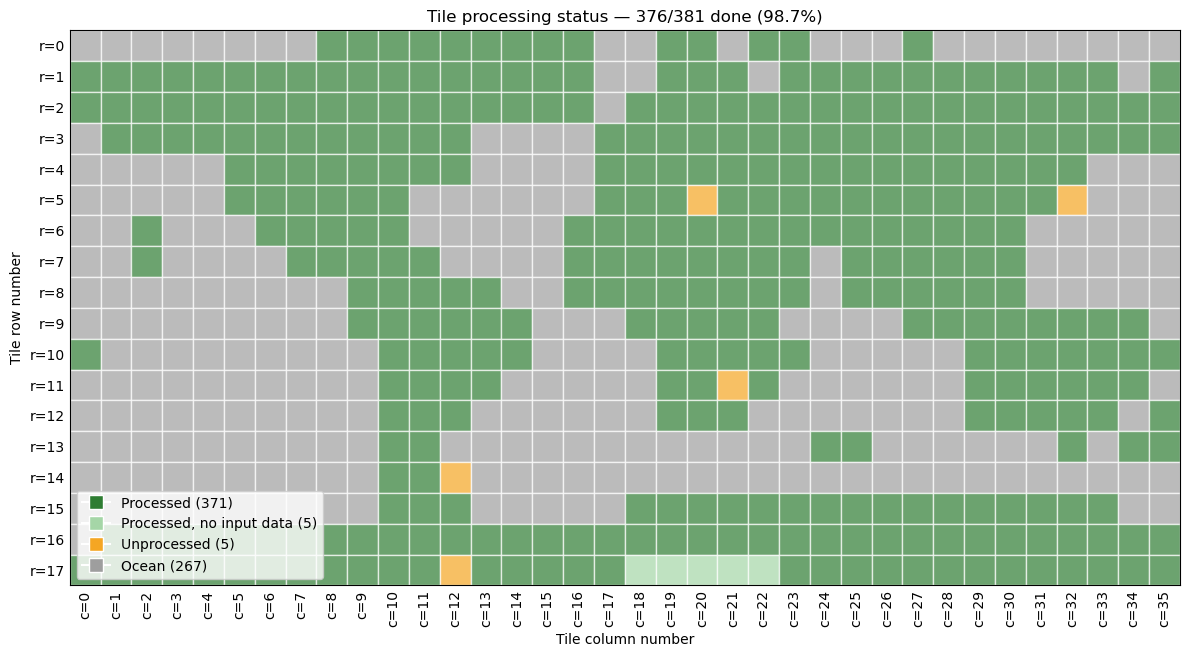

In [72]:
# show set half of processed tiles to unprocessed for conceptual figure
mock_status_gdf = status_gdf.copy()

processed_tiles = mock_status_gdf[mock_status_gdf["status"] == "processed"]
half_processed_tiles = processed_tiles.sample(frac=0.012, random_state=42).index
mock_status_gdf.loc[half_processed_tiles, "status"] = "unprocessed"

counts = mock_status_gdf["status"].value_counts()
land_count = int((mock_status_gdf["status"] != "ocean").sum())
processed_count = int(counts.get("processed", 0))
nodata_count = int(counts.get("nodata", 0))
unprocessed_count = int(counts.get("unprocessed", 0))

print(f"Land tiles:   {land_count}")
print(f"Processed:    {processed_count}")
print(f"No-data:      {nodata_count}")
print(f"Unprocessed:  {unprocessed_count}")
print(f"Progress:     {100 * (processed_count + nodata_count) / land_count:.1f}%")


color_map = {
    "processed": "#2e7d32",
    "nodata": "#a5d6a7",
    "unprocessed": "#f5a623",
    "ocean": "#9e9e9e",
}

f, ax = plt.subplots(figsize=(12, 7))
status_gdf.plot(
    ax=ax,
    color=mock_status_gdf["status"].map(color_map),
    edgecolor="white",
    alpha=0.7,
)

# ax.set_xlim(-180, 180)
# ax.set_ylim(-90, 90)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

ax.set_xlabel("Tile column number")
ax.set_ylabel("Tile row number")

col_values = sorted(mock_status_gdf["col"].unique())
row_values = sorted(mock_status_gdf["row"].unique(), reverse=True)
col_coords = [mock_status_gdf[mock_status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
row_coords = [mock_status_gdf[mock_status_gdf["row"] == v].geometry.centroid.y.mean() for v in row_values]

ax.set_xticks(col_coords)
ax.set_xticklabels([f"c={h}" for h in col_values], rotation=90)
ax.set_yticks(row_coords)
ax.set_yticklabels([f"r={v}" for v in row_values])
ax.tick_params(axis="both", which="both", length=0)
ax.set_xlim(mock_status_gdf.total_bounds[0], mock_status_gdf.total_bounds[2])
ax.set_ylim(mock_status_gdf.total_bounds[1], mock_status_gdf.total_bounds[3])

ax.set_title(
    f"Tile processing status — {processed_count + nodata_count}/{land_count} done "
    f"({100 * (processed_count + nodata_count) / land_count:.1f}%)"
)
handles = [
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed ({processed_count})", markerfacecolor=color_map["processed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed, no input data ({nodata_count})", markerfacecolor=color_map["nodata"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Unprocessed ({unprocessed_count})", markerfacecolor=color_map["unprocessed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Ocean ({int(counts.get('ocean', 0))})", markerfacecolor=color_map["ocean"], markersize=10),
]
ax.legend(handles=handles, loc="lower left")
f.tight_layout()
f.savefig('conceptual_figure/step_7_tile_processing_status_99pct.png', dpi=300)

Land tiles:   381
Processed:    376
No-data:      5
Unprocessed:  0
Progress:     100.0%


/tmp/ipykernel_6845/2793761415.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/2793761415.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/2793761415.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_6845/2793761415.py:

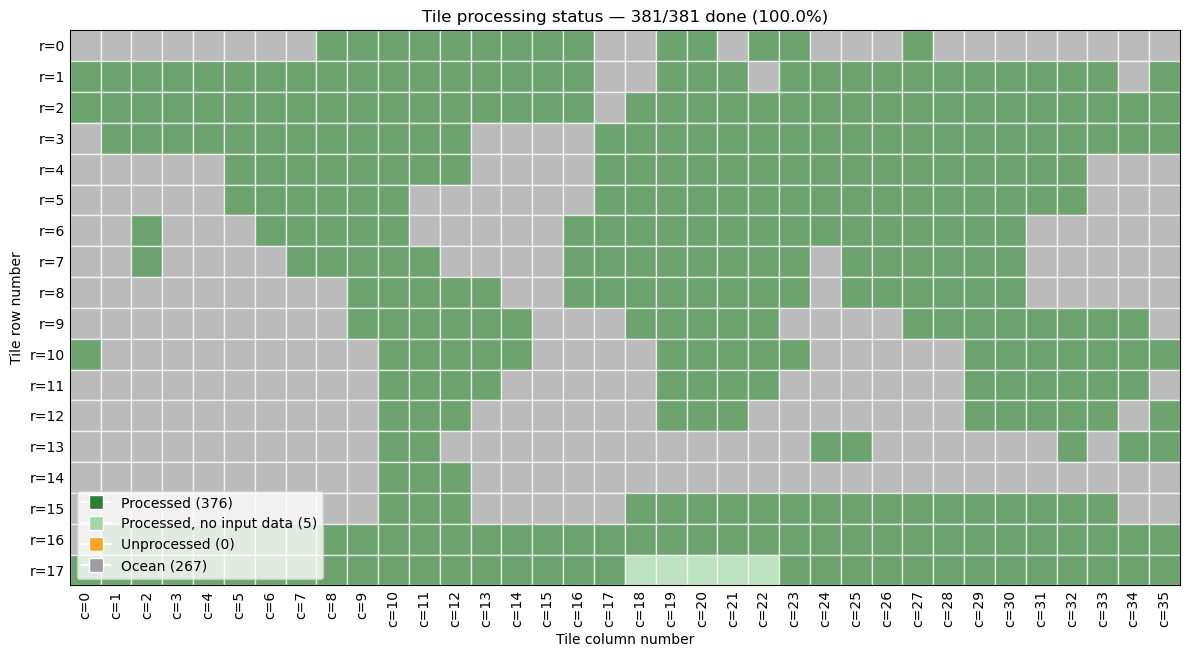

In [75]:
counts = status_gdf["status"].value_counts()
land_count = int((status_gdf["status"] != "ocean").sum())
processed_count = int(counts.get("processed", 0))
nodata_count = int(counts.get("nodata", 0))
unprocessed_count = int(counts.get("unprocessed", 0))

print(f"Land tiles:   {land_count}")
print(f"Processed:    {processed_count}")
print(f"No-data:      {nodata_count}")
print(f"Unprocessed:  {unprocessed_count}")
print(f"Progress:     {100 * (processed_count + nodata_count) / land_count:.1f}%")

color_map = {
    "processed": "#2e7d32",
    "nodata": "#a5d6a7",
    "unprocessed": "#f5a623",
    "ocean": "#9e9e9e",
}

f, ax = plt.subplots(figsize=(12, 7))
status_gdf.plot(
    ax=ax,
    color=status_gdf["status"].map(color_map),
    edgecolor="white",
    alpha=0.7,
)

# ax.set_xlim(-180, 180)
# ax.set_ylim(-90, 90)
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

ax.set_xlabel("Tile column number")
ax.set_ylabel("Tile row number")

col_values = sorted(status_gdf["col"].unique())
row_values = sorted(status_gdf["row"].unique(), reverse=True)
col_coords = [status_gdf[status_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
row_coords = [status_gdf[status_gdf["row"] == v].geometry.centroid.y.mean() for v in row_values]

ax.set_xticks(col_coords)
ax.set_xticklabels([f"c={h}" for h in col_values], rotation=90)
ax.set_yticks(row_coords)
ax.set_yticklabels([f"r={v}" for v in row_values])
ax.tick_params(axis="both", which="both", length=0)
ax.set_xlim(status_gdf.total_bounds[0], status_gdf.total_bounds[2])
ax.set_ylim(status_gdf.total_bounds[1], status_gdf.total_bounds[3])

ax.set_title(
    f"Tile processing status — {processed_count + nodata_count}/{land_count} done "
    f"({100 * (processed_count + nodata_count) / land_count:.1f}%)"
)
handles = [
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed ({processed_count})", markerfacecolor=color_map["processed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed, no input data ({nodata_count})", markerfacecolor=color_map["nodata"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Unprocessed ({unprocessed_count})", markerfacecolor=color_map["unprocessed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Ocean ({int(counts.get('ocean', 0))})", markerfacecolor=color_map["ocean"], markersize=10),
]
ax.legend(handles=handles, loc="lower left")
f.tight_layout()
f.savefig('conceptual_figure/step_8_tile_processing_status_100pct.png', dpi=300)